# Blockchain Alpha — Hourly Resolution Wallet Study

Re-evaluates the top 200 wallets from the random 10k daily study at **hourly resolution**.

Hypothesis: wallets showing weak or marginal signals at daily resolution may have strong signals at hourly resolution — daily aggregation washes out intraday precision.

**Validation window:** 2023-07-01 to 2024-12-31 (~18 months)
**Granularity:** hourly balance snapshots → hourly buy/sell/hold actions
**Horizons:** 1h, 4h, 12h, 24h, 72h forward returns
**Estimated cost:** ~$17  |  **Restart-safe:** yes

Key improvement over daily study: size-weighted scoring built in from the start, FDR correction on both unweighted and weighted p-values.

## 1. Configuration & imports

In [1]:
from claude_refactor_core_utils import *
from datetime import date, timedelta, datetime
import pandas as pd
import numpy as np
import os
import json
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# --- Required keys ---
ALCHEMY_API_KEY   = "8J0Ou3_XsuWVbOiZ0xpEvioGx7k0wab9"
ETHERSCAN_API_KEY = "GH6FVBANEIR1HS6PEN36XMYQRY2IDEAAXR"
assert ALCHEMY_API_KEY,   "Set ALCHEMY_API_KEY"
assert ETHERSCAN_API_KEY, "Set ETHERSCAN_API_KEY"

# --- Three-window boundaries ---
VALIDATION_START  = date(2023, 7, 1)
VALIDATION_END    = date(2024, 12, 31)

# --- Analysis config ---
N_TOP_WALLETS     = 200          # top N by raw 1d return diff from daily study
MIN_DELTA_ETH     = 0.005        # dust threshold
HORIZONS          = [1, 4, 12, 24, 72]   # forward return horizons in HOURS
FDR_ALPHA         = 0.05

# --- File paths ---
DAILY_SKILL_CSV          = '/home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv'
HOURLY_BLOCK_MAP_CSV     = '/home/colin/projects/blockchain_alpha/data/hourly_block_map.csv'
HOURLY_BALANCE_STORE_CSV = '/home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv'
HOURLY_SKILL_CSV         = '/home/colin/projects/blockchain_alpha/data/hourly_skill_results.csv'
EXISTING_BLOCK_MAP_CSV   = '/home/colin/projects/blockchain_alpha/data/warm_start_block_df.csv'

print(f"Validation window: {VALIDATION_START} to {VALIDATION_END}")
print(f"Window length: {(VALIDATION_END - VALIDATION_START).days} days = "
      f"~{(VALIDATION_END - VALIDATION_START).days * 24:,} hours")
print(f"Target wallets: {N_TOP_WALLETS}")

n_pairs = N_TOP_WALLETS * (VALIDATION_END - VALIDATION_START).days * 24
cost    = n_pairs * 19 / 1_000_000 * 0.45
print(f"Estimated pairs: {n_pairs:,}")
print(f"Estimated cost:  ${cost:.2f}")


Validation window: 2023-07-01 to 2024-12-31
Window length: 549 days = ~13,176 hours
Target wallets: 200
Estimated pairs: 2,635,200
Estimated cost:  $22.53


## 2. Select top 200 wallets

Loads daily skill results from `random_10k_skill_results.csv` and selects the top 200 by raw 1d return differential.

In [3]:
# Load daily skill results and select top N by raw 1d return diff
skill_df = pd.read_csv(DAILY_SKILL_CSV)
skill_df['address'] = skill_df['address'].str.lower().str.strip()

top_wallets_df = (
    skill_df[skill_df['horizon'] == 1]
    .sort_values('return_diff', ascending=False)
    .head(N_TOP_WALLETS)
    .copy()
)
top_wallets = top_wallets_df['address'].tolist()

print(f"Top {N_TOP_WALLETS} wallets selected")
print(f"1d return diff range: {top_wallets_df['return_diff'].min():.3f}% to {top_wallets_df['return_diff'].max():.3f}%")
print(f"p-value range: {top_wallets_df['p_value_raw'].min():.4f} to {top_wallets_df['p_value_raw'].max():.4f}")
print()
print("Distribution of daily return diffs:")
print(top_wallets_df['return_diff'].describe().round(3))


Top 200 wallets selected
1d return diff range: 1.060% to 3.024%
p-value range: 0.0017 to 0.3353

Distribution of daily return diffs:
count    200.000
mean       1.351
std        0.293
min        1.060
25%        1.155
50%        1.276
75%        1.432
max        3.024
Name: return_diff, dtype: float64


## 3. Hourly block map — interpolated from daily map

Rather than fetching ~13,000 hourly block numbers from Etherscan (~30 minutes at rate-limited speed), we interpolate from the existing daily block map. Ethereum produces ~7,200 blocks/day at ~12s intervals, so linear interpolation gives hourly estimates accurate to within a few blocks — more than sufficient for balance queries.

In [4]:
# Load existing daily block map
daily_block_df = pd.read_csv(EXISTING_BLOCK_MAP_CSV)
daily_block_df['timestamp'] = pd.to_datetime(daily_block_df['timestamp'])
daily_block_df['block_number'] = pd.to_numeric(daily_block_df['block_number'], errors='coerce')
daily_block_df = daily_block_df.dropna(subset=['block_number']).sort_values('timestamp')

print(f"Daily block map loaded: {len(daily_block_df):,} days")
print(f"Range: {daily_block_df['timestamp'].min().date()} to {daily_block_df['timestamp'].max().date()}")

# Build hourly index for validation window
hourly_index = pd.date_range(
    start=VALIDATION_START,
    end=VALIDATION_END,
    freq='h'
)

# Interpolate daily -> hourly block numbers
daily_indexed = (
    daily_block_df
    .set_index('timestamp')['block_number']
    .reindex(
        daily_block_df.set_index('timestamp').index.union(hourly_index)
    )
    .sort_index()
    .interpolate(method='index')
    .reindex(hourly_index)
    .round()
    .astype(int)
)

# Build block_map dict: pd.Timestamp -> block_number
block_map = {ts: int(bn) for ts, bn in daily_indexed.items()}

# Save for warm-start reference (lightweight)
hourly_block_df = pd.DataFrame({
    'timestamp':    list(block_map.keys()),
    'block_number': list(block_map.values())
})
hourly_block_df.to_csv(HOURLY_BLOCK_MAP_CSV, index=False)

print(f"Hourly block map: {len(block_map):,} hours")
print(f"Range: {min(block_map.keys())} to {max(block_map.keys())}")
print()

# Sanity check: blocks should increase monotonically and average ~300 blocks/hour
diffs = pd.Series(list(block_map.values())).diff().dropna()
print(f"Block increment stats (should be ~300/hour):")
print(f"  Mean:  {diffs.mean():.0f} blocks/hour")
print(f"  Std:   {diffs.std():.0f}")
print(f"  Min:   {diffs.min():.0f}")
print(f"  Max:   {diffs.max():.0f}")
print(f"  Monotonic: {(diffs > 0).all()}")


Daily block map loaded: 2,290 days
Range: 2020-01-01 to 2026-04-08
Hourly block map: 13,177 hours
Range: 2023-07-01 00:00:00 to 2024-12-31 00:00:00

Block increment stats (should be ~300/hour):
  Mean:  298 blocks/hour
  Std:   1
  Min:   285
  Max:   312
  Monotonic: True


## 4. Hourly ETH-USD prices (CryptoCompare)

Fetches hourly OHLCV and pre-computes forward returns at all horizons.

In [5]:
# Load hourly ETH-USD prices from CryptoCompare
print("Loading hourly ETH-USD prices from CryptoCompare...")
df_price_hourly = load_eth_usd_cryptocompare(
    start=str(VALIDATION_START),
    end=str(VALIDATION_END),
    interval='1h'
)
df_price_hourly['date'] = pd.to_datetime(df_price_hourly['date']).dt.floor('h')
df_price_hourly = df_price_hourly.sort_values('date').reset_index(drop=True)

# Compute forward returns at all horizons
for h in HORIZONS:
    df_price_hourly[f'fwd_return_{h}h']    = (
        df_price_hourly['close'].shift(-h) - df_price_hourly['close']
    ) / df_price_hourly['close'] * 100
    df_price_hourly[f'fwd_direction_{h}h'] = np.sign(df_price_hourly[f'fwd_return_{h}h'])

print(f"Hourly price data: {len(df_price_hourly):,} rows")
print(f"Range: {df_price_hourly['date'].min()} to {df_price_hourly['date'].max()}")
print()
print("Forward return stats:")
for h in HORIZONS:
    col = f'fwd_return_{h}h'
    print(f"  {h}h: mean={df_price_hourly[col].mean():.3f}%, std={df_price_hourly[col].std():.3f}%")


Loading hourly ETH-USD prices from CryptoCompare...
Hourly price data: 13,177 rows
Range: 2023-07-01 00:00:00 to 2024-12-31 00:00:00

Forward return stats:
  1h: mean=0.006%, std=0.612%
  4h: mean=0.024%, std=1.205%
  12h: mean=0.073%, std=2.102%
  24h: mean=0.147%, std=2.980%
  72h: mean=0.441%, std=5.208%


## 5. Build fetch schedule

In [6]:
# Build hourly fetch schedule: top 200 wallets x every hour in validation window
all_hours = sorted(block_map.keys())

print(f"Building schedule: {N_TOP_WALLETS} wallets x {len(all_hours):,} hours")

full_schedule = pd.DataFrame([
    {'address': addr, 'date': hour}
    for addr in top_wallets
    for hour in all_hours
])
full_schedule['date'] = pd.to_datetime(full_schedule['date']).dt.floor('h')

print(f"Total (address, hour) pairs: {len(full_schedule):,}")


Building schedule: 200 wallets x 13,177 hours
Total (address, hour) pairs: 2,635,400


## 6. Hourly balance fetch (restart-safe)

Fetches ETH balance for each wallet at each hourly block. Saves to `balance_store_hourly_top200.csv` after every hour. **Restart-safe:** already-fetched (address, hour) pairs are skipped automatically.

In [7]:
# ============================================================
# Hourly balance fetch — restart-safe
# Saves after every hour. Already-fetched pairs are skipped.
# ============================================================

def load_already_fetched_hourly(path):
    """Load set of already-fetched (address, hour) pairs."""
    if not os.path.exists(path):
        return set()
    df = pd.read_csv(path, usecols=['address', 'date'])
    df['date']    = pd.to_datetime(df['date'], format='mixed').dt.floor('h')
    df['address'] = df['address'].str.lower().str.strip()
    return set(zip(df['address'], df['date']))

print("Loading already-fetched pairs...")
already_fetched = load_already_fetched_hourly(HOURLY_BALANCE_STORE_CSV)
total_pairs     = len(full_schedule)
pct_done        = len(already_fetched) / total_pairs * 100 if total_pairs else 0
print(f"Already fetched: {len(already_fetched):,} / {total_pairs:,} ({pct_done:.1f}%)")
print()

fetch_count = 0
all_hours   = sorted(block_map.keys())

for i, hour in enumerate(all_hours):
    hour_norm = pd.Timestamp(hour).floor('h')
    block_num = block_map.get(hour_norm)

    if block_num is None:
        continue

    # Build schedule for this hour
    sched_hour = pd.DataFrame({
        'address': top_wallets,
        'date':    hour_norm
    })
    sched_hour['address'] = sched_hour['address'].str.lower().str.strip()

    # Filter to unfetched pairs
    mask = sched_hour.apply(
        lambda r: (r['address'], r['date']) not in already_fetched, axis=1
    )
    sched_new = sched_hour[mask].reset_index(drop=True)

    if not sched_new.empty:
        # Minimal block_df for this hour
        hour_block_df = pd.DataFrame([{
            'timestamp':    hour_norm,
            'block_number': block_num
        }])

        bal = fetch_balances_for_schedule(
            schedule=sched_new,
            block_df=hour_block_df,
            alchemy_api_key=ALCHEMY_API_KEY,
            batch_size=100,
            max_concurrency=30,
            rps=25.0,
            progress_every=500,
            block_date_col="timestamp",
            label=f"hourly-{str(hour_norm)[:13]}"
        )

        if not bal.empty:
            if os.path.exists(HOURLY_BALANCE_STORE_CSV):
                bal.to_csv(HOURLY_BALANCE_STORE_CSV, mode='a', header=False, index=False)
            else:
                bal.to_csv(HOURLY_BALANCE_STORE_CSV, index=False)

            bal['date_norm'] = pd.to_datetime(bal['date'], format='mixed').dt.floor('h')
            newly = set(zip(
                bal['address'].str.lower().str.strip(),
                bal['date_norm']
            ))
            already_fetched.update(newly)
            fetch_count += len(bal)

    # Progress every 24 hours (1 calendar day)
    if (i + 1) % 24 == 0 or (i + 1) == len(all_hours):
        pct = len(already_fetched) / total_pairs * 100
        print(f"[{i+1}/{len(all_hours)}] {str(hour_norm)[:13]} — "
              f"{len(already_fetched):,} pairs ({pct:.1f}% complete)")

print(f"\nFetch complete. {fetch_count:,} new rows written.")


Loading already-fetched pairs...
Already fetched: 0 / 2,635,400 (0.0%)

[hourly-2023-07-01 00] 2/2 batches (100.0%)
[hourly-2023-07-01 01] 2/2 batches (100.0%)
[hourly-2023-07-01 02] 2/2 batches (100.0%)
[hourly-2023-07-01 03] 2/2 batches (100.0%)
[hourly-2023-07-01 04] 2/2 batches (100.0%)
[hourly-2023-07-01 05] 2/2 batches (100.0%)
[hourly-2023-07-01 06] 2/2 batches (100.0%)
[hourly-2023-07-01 07] 2/2 batches (100.0%)
[hourly-2023-07-01 08] 2/2 batches (100.0%)
[hourly-2023-07-01 09] 2/2 batches (100.0%)
[hourly-2023-07-01 10] 2/2 batches (100.0%)
[hourly-2023-07-01 11] 2/2 batches (100.0%)
[hourly-2023-07-01 12] 2/2 batches (100.0%)
[hourly-2023-07-01 13] 2/2 batches (100.0%)
[hourly-2023-07-01 14] 2/2 batches (100.0%)
[hourly-2023-07-01 15] 2/2 batches (100.0%)
[hourly-2023-07-01 16] 2/2 batches (100.0%)
[hourly-2023-07-01 17] 2/2 batches (100.0%)
[hourly-2023-07-01 18] 2/2 batches (100.0%)
[hourly-2023-07-01 19] 2/2 batches (100.0%)
[hourly-2023-07-01 20] 2/2 batches (100.0%)
[hou

## 7. Load hourly balance store

In [24]:
# Fix the date column in the existing CSV — add hour back from block_number
# We can recover the hour by matching block_number back to our block_map

print("Fixing date precision in hourly balance store...")

raw = pd.read_csv(HOURLY_BALANCE_STORE_CSV)
print(f"Raw rows: {len(raw):,}")
print(f"Sample dates before fix: {raw['date'].head(3).tolist()}")

# Build reverse lookup: block_number -> hour timestamp
block_to_hour = {v: k for k, v in block_map.items()}

# The block_number column tells us exactly which hour this row belongs to
raw['block_number'] = pd.to_numeric(raw['block_number'], errors='coerce').astype('Int64')

# Match each block_number to its hour
raw['date_fixed'] = raw['block_number'].map(block_to_hour)

# How many matched?
n_matched = raw['date_fixed'].notna().sum()
print(f"Matched to hourly timestamp: {n_matched:,} / {len(raw):,}")

# Use fixed date where available, fall back to original
raw['date'] = raw['date_fixed'].combine_first(pd.to_datetime(raw['date'], format='mixed'))
raw = raw.drop(columns=['date_fixed'])

# Save fixed version
raw.to_csv(HOURLY_BALANCE_STORE_CSV, index=False)
print(f"Saved fixed CSV with hourly timestamps")
print(f"Sample dates after fix: {raw['date'].head(3).tolist()}")

Fixing date precision in hourly balance store...
Raw rows: 2,648,577
Sample dates before fix: ['2023-07-01 00:00:00', '2023-07-01 00:00:00', '2023-07-01 00:00:00']
Matched to hourly timestamp: 2,648,577 / 2,648,577
Saved fixed CSV with hourly timestamps
Sample dates after fix: [Timestamp('2023-07-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2023-07-01 00:00:00')]


In [25]:
# Load and clean hourly balance store
print("Loading hourly balance store...")
raw = pd.read_csv(HOURLY_BALANCE_STORE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.floor('h')
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')
raw['block_number']= pd.to_numeric(raw['block_number'], errors='coerce').astype('Int64')

# Deduplicate
hourly_balances = (
    raw
    .sort_values(['address', 'date', 'block_number'])
    .groupby(['address', 'date'], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
hourly_balances['balance_eth'] = hourly_balances['balance_wei'] / 1e18

expected = N_TOP_WALLETS * len(all_hours)
coverage = hourly_balances.shape[0] / expected * 100

print(f"Hourly balance store: {hourly_balances.shape[0]:,} rows")
print(f"Unique addresses:     {hourly_balances['address'].nunique():,}")
print(f"Date range:           {hourly_balances['date'].min()} to {hourly_balances['date'].max()}")
print(f"Coverage:             {coverage:.1f}% of expected pairs")


Loading hourly balance store...
Hourly balance store: 2,648,577 rows
Unique addresses:     201
Date range:           2023-07-01 00:00:00 to 2024-12-31 00:00:00
Coverage:             100.5% of expected pairs


In [26]:
# Diagnostic — check raw file before any processing
raw_check = pd.read_csv(HOURLY_BALANCE_STORE_CSV, nrows=5)
print(raw_check)
print()
print(f"Raw file row count:")
import subprocess
result = subprocess.run(['wc', '-l', HOURLY_BALANCE_STORE_CSV], 
                       capture_output=True, text=True)
print(result.stdout)

                                      address                 date  \
0  0x01f06d1200782e5bbe5fd134ce0ca3fe0c86d854  2023-07-01 00:00:00   
1  0x1739e3b5173f4225b1f566b7ca86b8213c185b9e  2023-07-01 00:00:00   
2  0x1c9f76ac9c4dd08a44c5dfe560259e5593769e15  2023-07-01 00:00:00   
3  0x1d51e5066e7a570a17201d8ae08abf664521cea8  2023-07-01 00:00:00   
4  0x3149c24b56c1097d784f1630f8d5cc60593776ae  2023-07-01 00:00:00   

   block_number         balance_wei  
0      17596995                   0  
1      17596995                   0  
2      17596995  250118263661792000  
3      17596995                   0  
4      17596995   62348750000000000  

Raw file row count:
2648578 /home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv



## 8. Infer hourly actions

Buy/sell/hold classified from hour-over-hour balance delta. Dust threshold: 0.005 ETH.

In [27]:
# Infer hourly buy/sell/hold from balance deltas
print("Inferring hourly actions...")
hourly_balances = hourly_balances.sort_values(['address', 'date'])
hourly_balances['delta_eth'] = hourly_balances.groupby('address')['balance_eth'].diff()

def classify_action(delta):
    if pd.isna(delta): return None
    if delta >  MIN_DELTA_ETH: return 'buy'
    if delta < -MIN_DELTA_ETH: return 'sell'
    return 'hold'

hourly_balances['action'] = hourly_balances['delta_eth'].apply(classify_action)
hourly_actions = hourly_balances.dropna(subset=['action']).copy()

print(f"Hourly action observations: {len(hourly_actions):,}")
print(f"Active wallets: {hourly_actions['address'].nunique():,}")
print()
print("Action distribution:")
print(hourly_actions['action'].value_counts())
print()

# Trade count per wallet
buy_counts = hourly_actions[hourly_actions['action']=='buy'].groupby('address').size()
print("Buy trade count distribution (hourly):")
print(buy_counts.describe().round(1))
print(f"Wallets with >= 20 hourly buys:  {(buy_counts >= 20).sum()}")
print(f"Wallets with >= 50 hourly buys:  {(buy_counts >= 50).sum()}")
print(f"Wallets with >= 100 hourly buys: {(buy_counts >= 100).sum()}")

active_hourly = buy_counts[buy_counts >= 20].index.tolist()
hourly_actions_filtered = hourly_actions[hourly_actions['address'].isin(active_hourly)].copy()
print(f"\nFiltered to >= 20 hourly buy trades: {len(active_hourly)} wallets")


Inferring hourly actions...
Hourly action observations: 2,648,376
Active wallets: 201

Action distribution:
action
hold    2626563
buy       12021
sell       9792
Name: count, dtype: int64

Buy trade count distribution (hourly):
count     157.0
mean       76.6
std       365.3
min         1.0
25%         3.0
50%        10.0
75%        36.0
max      4353.0
dtype: float64
Wallets with >= 20 hourly buys:  55
Wallets with >= 50 hourly buys:  30
Wallets with >= 100 hourly buys: 18

Filtered to >= 20 hourly buy trades: 55 wallets


## 9. Merge forward returns

In [28]:
# Merge hourly forward returns onto actions
trade_df = hourly_actions_filtered.merge(
    df_price_hourly[['date'] +
                     [f'fwd_return_{h}h' for h in HORIZONS] +
                     [f'fwd_direction_{h}h' for h in HORIZONS]],
    on='date', how='inner'
)

print(f"Trade observations with price data: {len(trade_df):,}")
print(f"Unique wallets: {trade_df['address'].nunique():,}")
print()
print("Forward return baseline stats (all observations):")
for h in HORIZONS:
    col = f'fwd_return_{h}h'
    print(f"  {h}h: mean={trade_df[col].mean():.3f}%, std={trade_df[col].std():.3f}%")


Trade observations with price data: 724,680
Unique wallets: 55

Forward return baseline stats (all observations):
  1h: mean=0.006%, std=0.612%
  4h: mean=0.024%, std=1.205%
  12h: mean=0.073%, std=2.102%
  24h: mean=0.147%, std=2.980%
  72h: mean=0.441%, std=5.208%


## 10. Hourly skill scoring

Size-weighted forward return scoring at hourly resolution. Both unweighted and size-weighted p-values computed. FDR correction applied per horizon on both.

In [29]:
# ============================================================
# Hourly wallet-level skill scoring — size-weighted
# ============================================================
print("Computing hourly skill scores (size-weighted)...")
print()

skill_rows = []
buys_df  = trade_df[trade_df['action']=='buy'].copy()
buy_grps = buys_df.groupby('address')

for h in HORIZONS:
    col     = f'fwd_return_{h}h'
    dir_col = f'fwd_direction_{h}h'

    base_mean = trade_df[col].mean()
    base_std  = trade_df[col].std()
    base_n    = trade_df[col].notna().sum()
    base_dir  = (trade_df[dir_col].dropna() > 0).mean()

    print(f"  {h}h horizon...")

    for addr in active_hourly:
        if addr not in buy_grps.groups:
            continue

        grp      = buy_grps.get_group(addr)
        buy_ret  = grp[col].dropna()
        weights  = grp.loc[buy_ret.index, 'delta_eth'].values

        if len(buy_ret) < 10 or weights.sum() == 0:
            continue

        # Unweighted stats
        buy_mean = buy_ret.mean()
        buy_std  = buy_ret.std()
        buy_n    = len(buy_ret)

        # Size-weighted stats
        wtd_mean = np.average(buy_ret.values, weights=weights)
        wtd_var  = np.average((buy_ret.values - wtd_mean)**2, weights=weights)
        wtd_std  = np.sqrt(wtd_var)
        n_eff    = (weights.sum()**2) / (weights**2).sum()

        # Welch t-test (unweighted vs population)
        se_u = np.sqrt(buy_std**2/buy_n + base_std**2/base_n)
        p_unwtd = 1.0
        if se_u > 0:
            t_u  = (buy_mean - base_mean) / se_u
            df_u = (buy_std**2/buy_n + base_std**2/base_n)**2 /                    ((buy_std**2/buy_n)**2/(buy_n-1) + (base_std**2/base_n)**2/(base_n-1))
            p_unwtd = 2 * stats.t.sf(abs(t_u), df=df_u)

        # Welch t-test (size-weighted vs population)
        se_w = np.sqrt(wtd_std**2/n_eff + base_std**2/base_n)
        p_wtd = 1.0
        if se_w > 0:
            t_w  = (wtd_mean - base_mean) / se_w
            df_w = (wtd_std**2/n_eff + base_std**2/base_n)**2 /                    ((wtd_std**2/n_eff)**2/(n_eff-1) + (base_std**2/base_n)**2/(base_n-1))
            p_wtd = 2 * stats.t.sf(abs(t_w), df=df_w)

        buy_dir_acc = (grp[dir_col].dropna() > 0).mean()
        wtd_dir_acc = np.average((grp[dir_col].dropna() > 0).astype(float),
                                  weights=grp.loc[grp[dir_col].notna(), 'delta_eth'].values)

        skill_rows.append({
            'address':          addr,
            'horizon_h':        h,
            'n_buy_trades':     buy_n,
            'n_eff':            round(n_eff, 1),
            'buy_mean_return':  buy_mean,
            'wtd_mean_return':  wtd_mean,
            'baseline_mean':    base_mean,
            'return_diff':      buy_mean - base_mean,
            'wtd_return_diff':  wtd_mean - base_mean,
            'dir_accuracy':     buy_dir_acc,
            'wtd_dir_accuracy': wtd_dir_acc,
            'baseline_dir':     base_dir,
            'p_value_unwtd':    p_unwtd,
            'p_value_wtd':      p_wtd,
        })

skill_hourly_df = pd.DataFrame(skill_rows)

# FDR correction — both unweighted and weighted
print("\nApplying FDR correction...")
for h in HORIZONS:
    mask = skill_hourly_df['horizon_h'] == h

    for col_p, col_fdr, col_sig in [
        ('p_value_unwtd', 'p_fdr_unwtd', 'sig_fdr_unwtd'),
        ('p_value_wtd',   'p_fdr_wtd',   'sig_fdr_wtd'),
    ]:
        pvals  = skill_hourly_df.loc[mask, col_p].values
        reject, pvals_fdr, _, _ = multipletests(pvals, alpha=FDR_ALPHA, method='fdr_bh')
        skill_hourly_df.loc[mask, col_fdr] = pvals_fdr
        skill_hourly_df.loc[mask, col_sig] = reject.astype(bool)

    n_sig_u = skill_hourly_df.loc[mask, 'sig_fdr_unwtd'].sum()
    n_sig_w = skill_hourly_df.loc[mask, 'sig_fdr_wtd'].sum()
    n_tot   = mask.sum()
    print(f"  {h}h: FDR sig unweighted={n_sig_u}, weighted={n_sig_w} (of {n_tot} wallets)")

positive_skill = skill_hourly_df[
    skill_hourly_df['sig_fdr_wtd'] & (skill_hourly_df['wtd_return_diff'] > 0)
]
print(f"\nFDR-significant positive wallets (size-weighted, any horizon):")
print(f"  {positive_skill['address'].nunique()}")


Computing hourly skill scores (size-weighted)...

  1h horizon...
  4h horizon...
  12h horizon...
  24h horizon...
  72h horizon...

Applying FDR correction...
  1h: FDR sig unweighted=0, weighted=0 (of 55 wallets)
  4h: FDR sig unweighted=2, weighted=0 (of 55 wallets)
  12h: FDR sig unweighted=0, weighted=0 (of 55 wallets)
  24h: FDR sig unweighted=2, weighted=0 (of 55 wallets)
  72h: FDR sig unweighted=4, weighted=0 (of 55 wallets)

FDR-significant positive wallets (size-weighted, any horizon):
  0


## 11. Compare hourly vs daily results

For the same wallets — did moving to hourly resolution reveal signal that daily aggregation was hiding?

In [30]:
# ============================================================
# Compare hourly vs daily results for same wallets
# ============================================================
print("=== HOURLY vs DAILY COMPARISON ===")
print()

# Load daily extended skill results for comparison
try:
    daily_ext = pd.read_csv('/home/colin/projects/blockchain_alpha/data/top500_extended_skill_results.csv')
    daily_ext['address'] = daily_ext['address'].str.lower().str.strip()
    has_daily = True
except:
    has_daily = False
    print("Daily extended results not found — skipping comparison")

if has_daily:
    # Compare at 1d daily vs 24h hourly
    daily_1d = daily_ext[daily_ext['horizon'] == 1][
        ['address','n_buy_trades','return_diff','p_value_raw','significant_fdr']
    ].copy()
    daily_1d.columns = ['address','n_buys_daily','diff_daily','p_daily','sig_daily']

    hourly_24h = skill_hourly_df[skill_hourly_df['horizon_h'] == 24][
        ['address','n_buy_trades','wtd_return_diff','p_value_wtd','sig_fdr_wtd']
    ].copy()
    hourly_24h.columns = ['address','n_buys_hourly','diff_hourly_wtd','p_hourly','sig_hourly']

    compare = daily_1d.merge(hourly_24h, on='address', how='inner')

    print(f"Wallets in both daily and hourly analysis: {len(compare)}")
    print()
    print(f"Daily 1d FDR significant:      {compare['sig_daily'].sum()}")
    print(f"Hourly 24h FDR significant:    {compare['sig_hourly'].sum()}")
    print()

    # Signal improvement: how many gained significance at hourly?
    gained = compare[~compare['sig_daily'] & compare['sig_hourly']]
    lost   = compare[compare['sig_daily'] & ~compare['sig_hourly']]
    print(f"Wallets gaining significance at hourly: {len(gained)}")
    print(f"Wallets losing significance at hourly:  {len(lost)}")
    print()

    # Top 20 by hourly weighted return diff
    print("Top 20 by hourly 24h weighted return diff:")
    top20 = compare.sort_values('diff_hourly_wtd', ascending=False).head(20)
    print(top20[['address','n_buys_daily','n_buys_hourly',
                 'diff_daily','diff_hourly_wtd',
                 'p_daily','p_hourly','sig_hourly']].to_string())


=== HOURLY vs DAILY COMPARISON ===

Wallets in both daily and hourly analysis: 55

Daily 1d FDR significant:      0
Hourly 24h FDR significant:    0

Wallets gaining significance at hourly: 0
Wallets losing significance at hourly:  0

Top 20 by hourly 24h weighted return diff:
                                       address  n_buys_daily  n_buys_hourly  diff_daily  diff_hourly_wtd   p_daily  p_hourly sig_hourly
7   0xbd4c4049bf7b42889d343384743a808f9d6a1f45            62             24    0.593333         1.696896  0.241954  0.077035      False
12  0xd46c478b9ab796dda9f7ff1d3c6c7322dd742dbe            33             26    1.379147         1.324511  0.035528  0.137932      False
45  0xf7b10d603907658f690da534e9b7dbc4dab3e2d6           149             39    0.582096         1.285550  0.164672  0.238757      False
6   0xbc3ff0efc1c7dd94516d91a582516271de0768ff            38             72    1.069665         1.212650  0.107028  0.188539      False
38  0xf597635022d89b9486a14205125cabe9508d

## 12. Top skilled wallets at hourly resolution

In [31]:
# ============================================================
# Top skilled wallets at hourly resolution
# ============================================================

best_h = HORIZONS[0]  # start with 1h
for h in HORIZONS:
    n = positive_skill[positive_skill['horizon_h']==h]['address'].nunique()
    if n > 0:
        best_h = h
        break

print(f"=== TOP WALLETS — HOURLY RESOLUTION ({best_h}h horizon) ===")
top_hourly = (
    skill_hourly_df[skill_hourly_df['horizon_h']==best_h]
    .sort_values('wtd_return_diff', ascending=False)
    .head(30)
)
print(top_hourly[['address','n_buy_trades','n_eff',
                   'wtd_mean_return','baseline_mean','wtd_return_diff',
                   'wtd_dir_accuracy','p_value_wtd','p_fdr_wtd','sig_fdr_wtd'
                   ]].to_string())
print()

# Summary across all horizons
print("=== FDR-SIGNIFICANT POSITIVE WALLETS BY HORIZON ===")
for h in HORIZONS:
    pos = skill_hourly_df[
        (skill_hourly_df['horizon_h']==h) &
        skill_hourly_df['sig_fdr_wtd'] &
        (skill_hourly_df['wtd_return_diff']>0)
    ]
    tot = skill_hourly_df[skill_hourly_df['horizon_h']==h]['address'].nunique()
    print(f"  {h}h: {pos['address'].nunique()} / {tot} wallets "
          f"({pos['address'].nunique()/tot*100:.2f}%)")


=== TOP WALLETS — HOURLY RESOLUTION (1h horizon) ===
                                       address  n_buy_trades  n_eff  wtd_mean_return  baseline_mean  wtd_return_diff  wtd_dir_accuracy  p_value_wtd  p_fdr_wtd sig_fdr_wtd
41  0xf6a9bad6caea9dec2d5dc22804865cb522bdc2f8           122    9.2         0.467312       0.006004         0.461307          0.747286     0.040665   0.641765       False
13  0xd64f2bbb92810e111f913f1c511d64f5eff03c8d            20    8.4         0.458071       0.006004         0.452066          0.681032     0.226719   0.792287       False
15  0xe0df602386d6c5fba1905033c3fe4214ed796305            48    9.3         0.363421       0.006004         0.357416          0.611561     0.325124   0.793364       False
32  0xefef0fdac242c7b7ac6644b1745dea24edcde030            30   11.1         0.331634       0.006004         0.325629          0.762737     0.081909   0.641765       False
52  0xfc06cc834874c6d424b6ebf4a7a48042daa2d267            73   17.2         0.294684       0

In [32]:
target = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'
if target in skill_hourly_df['address'].values:
    print(skill_hourly_df[skill_hourly_df['address']==target][
        ['horizon_h','n_buy_trades','n_eff','wtd_return_diff',
         'wtd_dir_accuracy','p_value_wtd','p_fdr_wtd']
    ].to_string())
else:
    print("Not in hourly study — not in top 200 daily wallets")

     horizon_h  n_buy_trades  n_eff  wtd_return_diff  wtd_dir_accuracy  p_value_wtd  p_fdr_wtd
0            1           435   45.8         0.157815          0.631957     0.070575   0.641765
55           4           435   45.8        -0.047317          0.509615     0.791023   0.988620
110         12           435   45.8        -0.221995          0.540272     0.395165   0.777171
165         24           435   45.8         0.047717          0.468185     0.896121   0.987763
220         72           435   45.8         1.427583          0.639190     0.071977   0.701397


In [33]:
# Check where 0x1b4b91bb ranks in the daily skill results
target = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'
skill_1d = skill_df[skill_df['horizon'] == 1].sort_values('return_diff', ascending=False).reset_index(drop=True)
skill_1d['rank'] = skill_1d.index + 1

match = skill_1d[skill_1d['address'] == target]
if len(match) > 0:
    print(f"Rank in 1d return diff: {match['rank'].iloc[0]} of {len(skill_1d)}")
    print(match[['address','n_buy_trades','return_diff','dir_accuracy','p_value_raw']].to_string())
else:
    print("Not found in skill_df — wallet wasn't in the random 10k study at all")

Rank in 1d return diff: 474 of 8077
                                        address  n_buy_trades  return_diff  dir_accuracy  p_value_raw
473  0x1b4b91bb747176451f0f7f73b636babafcf31cc4            73      0.73498      0.616438     0.044406


In [34]:
target = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'

target_actions = hourly_actions[hourly_actions['address'] == target].copy()
target_buys = target_actions[target_actions['action'] == 'buy'].copy()

print(f"Total hourly observations: {len(target_actions):,}")
print(f"Hourly buys: {len(target_buys)}")
print(f"Hourly sells: {len(target_actions[target_actions['action']=='sell'])}")
print()
print("Monthly buy count:")
target_buys['month'] = target_buys['date'].dt.to_period('M')
print(target_buys.groupby('month').size().to_string())

Total hourly observations: 13,176
Hourly buys: 435
Hourly sells: 534

Monthly buy count:
month
2023-07     7
2023-08     4
2023-09    22
2023-10    75
2023-11    50
2023-12    55
2024-01    16
2024-02    58
2024-03    14
2024-04    16
2024-05    39
2024-06    13
2024-07     4
2024-08     3
2024-09    22
2024-10    12
2024-11    12
2024-12    13
Freq: M


# Our super-wallet didnt make the 1d criteria used for these wallets.  adding it manually

In [21]:
# Add confirmed skilled wallet to the hourly study
target = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'

# Add to top_wallets list
if target not in top_wallets:
    top_wallets.append(target)
    print(f"Added {target} to wallet list")
    print(f"New wallet count: {len(top_wallets)}")

# Build schedule for just this wallet
target_schedule = pd.DataFrame({
    'address': [target] * len(all_hours),
    'date':    all_hours
})
target_schedule['address'] = target_schedule['address'].str.lower().str.strip()

# Filter to unfetched pairs
already_fetched_now = load_already_fetched_hourly(HOURLY_BALANCE_STORE_CSV)
mask = target_schedule.apply(
    lambda r: (r['address'], r['date']) not in already_fetched_now, axis=1
)
target_new = target_schedule[mask].reset_index(drop=True)
print(f"Hours to fetch: {len(target_new):,}")

Added 0x1b4b91bb747176451f0f7f73b636babafcf31cc4 to wallet list
New wallet count: 201
Hours to fetch: 13,177


In [22]:
# Fetch hourly balances for the single added wallet
fetch_count_target = 0

for i, hour in enumerate(all_hours):
    hour_norm = pd.Timestamp(hour).floor('h')
    block_num = block_map.get(hour_norm)

    if block_num is None:
        continue

    sched_row = pd.DataFrame({
        'address': [target],
        'date':    [hour_norm]
    })
    sched_row['address'] = sched_row['address'].str.lower().str.strip()

    mask = sched_row.apply(
        lambda r: (r['address'], r['date']) not in already_fetched_now, axis=1
    )
    sched_new = sched_row[mask].reset_index(drop=True)

    if not sched_new.empty:
        hour_block_df = pd.DataFrame([{
            'timestamp':    hour_norm,
            'block_number': block_num
        }])

        bal = fetch_balances_for_schedule(
            schedule=sched_new,
            block_df=hour_block_df,
            alchemy_api_key=ALCHEMY_API_KEY,
            batch_size=100,
            max_concurrency=30,
            rps=25.0,
            progress_every=5000,
            block_date_col="timestamp",
            label=f"target-{str(hour_norm)[:13]}"
        )

        if not bal.empty:
            # Fix date precision using block_map reverse lookup
            block_to_hour = {v: k for k, v in block_map.items()}
            bal['block_number_int'] = pd.to_numeric(bal['block_number'], errors='coerce').astype('Int64')
            bal['date'] = bal['block_number_int'].map(block_to_hour)
            bal = bal.drop(columns=['block_number_int'])

            if os.path.exists(HOURLY_BALANCE_STORE_CSV):
                bal.to_csv(HOURLY_BALANCE_STORE_CSV, mode='a', header=False, index=False)
            else:
                bal.to_csv(HOURLY_BALANCE_STORE_CSV, index=False)

            fetch_count_target += len(bal)

    if (i + 1) % 1000 == 0 or (i + 1) == len(all_hours):
        print(f"[{i+1}/{len(all_hours)}] {str(hour_norm)[:13]} — {fetch_count_target:,} rows")

print(f"\nDone. {fetch_count_target:,} rows fetched for target wallet.")

[target-2023-07-01 00] 1/1 batches (100.0%)
[target-2023-07-01 01] 1/1 batches (100.0%)
[target-2023-07-01 02] 1/1 batches (100.0%)
[target-2023-07-01 03] 1/1 batches (100.0%)
[target-2023-07-01 04] 1/1 batches (100.0%)
[target-2023-07-01 05] 1/1 batches (100.0%)
[target-2023-07-01 06] 1/1 batches (100.0%)
[target-2023-07-01 07] 1/1 batches (100.0%)
[target-2023-07-01 08] 1/1 batches (100.0%)
[target-2023-07-01 09] 1/1 batches (100.0%)
[target-2023-07-01 10] 1/1 batches (100.0%)
[target-2023-07-01 11] 1/1 batches (100.0%)
[target-2023-07-01 12] 1/1 batches (100.0%)
[target-2023-07-01 13] 1/1 batches (100.0%)
[target-2023-07-01 14] 1/1 batches (100.0%)
[target-2023-07-01 15] 1/1 batches (100.0%)
[target-2023-07-01 16] 1/1 batches (100.0%)
[target-2023-07-01 17] 1/1 batches (100.0%)
[target-2023-07-01 18] 1/1 batches (100.0%)
[target-2023-07-01 19] 1/1 batches (100.0%)
[target-2023-07-01 20] 1/1 batches (100.0%)
[target-2023-07-01 21] 1/1 batches (100.0%)
[target-2023-07-01 22] 1/1 batch

## 13. Visualization

KeyError: "None of [Index([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,\n       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,\n       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],\n      dtype='object')] are in the [columns]"

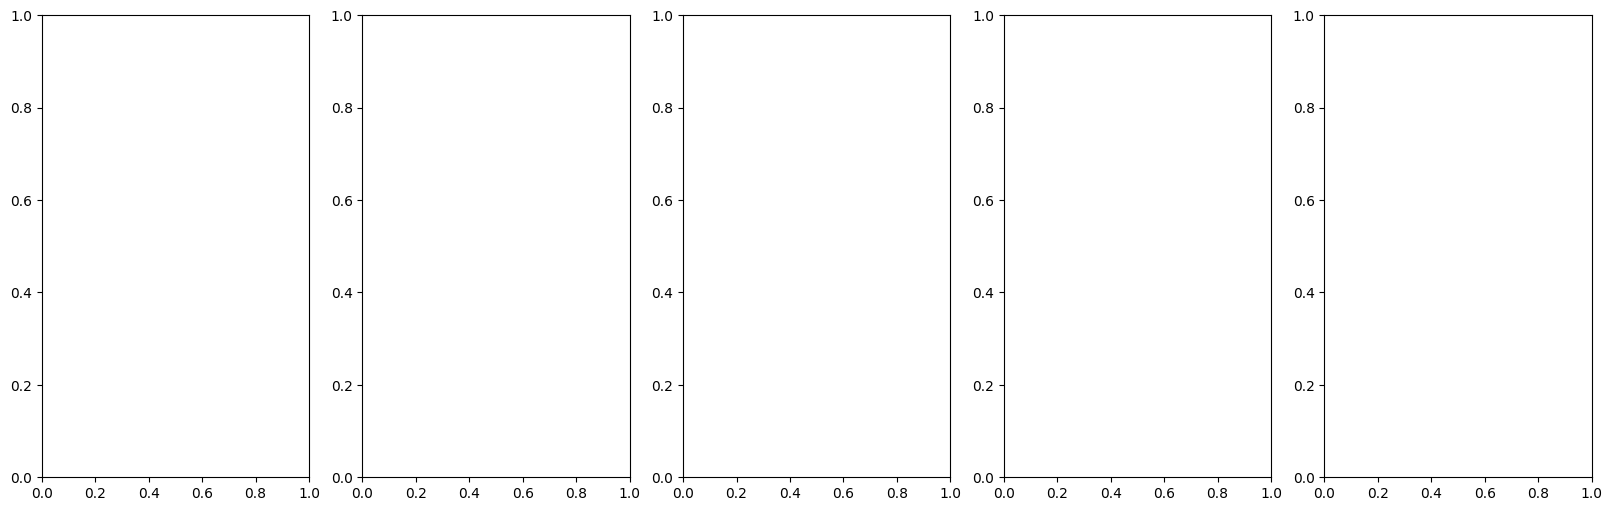

In [18]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(20, 6))

for idx, h in enumerate(HORIZONS):
    ax = axes[idx]
    df_h = skill_hourly_df[skill_hourly_df['horizon_h']==h].copy()

    sig   = df_h[df_h['sig_fdr_wtd'] & (df_h['wtd_return_diff']>0)]['wtd_return_diff']
    unsig = df_h[~df_h['sig_fdr_wtd']]['wtd_return_diff']

    ax.hist(unsig, bins=40, alpha=0.6, color='gray',
            label=f'Not sig (n={len(unsig):,})', density=True)
    if len(sig) > 0:
        ax.hist(sig, bins=10, alpha=0.8, color='steelblue',
                label=f'FDR sig (n={len(sig):,})', density=True)

    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Baseline')
    ax.set_title(f'{h}h forward return\nweighted diff distribution')
    ax.set_xlabel('Wtd return diff (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Hourly Skill Distribution — Top 200 Wallets', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 14. Save results

In [35]:
skill_hourly_df.to_csv(HOURLY_SKILL_CSV, index=False)
print(f"Hourly skill results saved: {HOURLY_SKILL_CSV}")
print(f"Shape: {skill_hourly_df.shape}")
print()
print("=" * 60)
print("FINAL SUMMARY — HOURLY RESOLUTION")
print("=" * 60)
print(f"Wallets analyzed:   {skill_hourly_df['address'].nunique():,}")
print(f"Validation window:  {VALIDATION_START} to {VALIDATION_END}")
print()
print("FDR-significant positive wallets (size-weighted):")
for h in HORIZONS:
    n   = positive_skill[positive_skill['horizon_h']==h]['address'].nunique()
    tot = skill_hourly_df[skill_hourly_df['horizon_h']==h]['address'].nunique()
    print(f"  {h}h: {n} wallets ({n/tot*100:.2f}% of {tot} active)")
print()
n_any = positive_skill['address'].nunique()
n_tot = skill_hourly_df['address'].nunique()
print(f"Significant on any horizon: {n_any} / {n_tot} ({n_any/n_tot*100:.2f}%)")


Hourly skill results saved: /home/colin/projects/blockchain_alpha/data/hourly_skill_results.csv
Shape: (275, 18)

FINAL SUMMARY — HOURLY RESOLUTION
Wallets analyzed:   55
Validation window:  2023-07-01 to 2024-12-31

FDR-significant positive wallets (size-weighted):
  1h: 0 wallets (0.00% of 55 active)
  4h: 0 wallets (0.00% of 55 active)
  12h: 0 wallets (0.00% of 55 active)
  24h: 0 wallets (0.00% of 55 active)
  72h: 0 wallets (0.00% of 55 active)

Significant on any horizon: 0 / 55 (0.00%)
